<a href="https://colab.research.google.com/github/Anakha10/northstar-analytics/blob/main/NorthStar_R_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
install.packages("sqldf")
install.packages("ggplot2")
install.packages("dplyr")

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘RSQLite’, ‘chron’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



In [2]:
library(sqldf)
library(ggplot2)
library(dplyr)

Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”
Loading required package: RSQLite


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [3]:
deliveries <- read.csv("deliveries.csv")
drivers <- read.csv("drivers.csv")
hubs <- read.csv("hubs.csv")
complaints <- read.csv("complaints.csv")

In [4]:
sqldf("
SELECT delivery_status, COUNT(*) as total
FROM deliveries
GROUP BY delivery_status
")

delivery_status,total
<chr>,<int>
Delayed,202
Failed,132
OnTime,616


In [5]:
sqldf("
SELECT AVG(fuel_or_charge_cost) as avg_cost
FROM deliveries
")

avg_cost
<dbl>
12.84129


In [6]:
sqldf("
SELECT AVG(manual_route_override_count) as avg_override
FROM deliveries
")

avg_override
<dbl>
0.9694737


In [7]:
sqldf("
SELECT d.delivery_id,
       d.delivery_status,
       dr.driver_rating
FROM deliveries d
JOIN drivers dr
ON d.driver_id = dr.driver_id
LIMIT 10
")

delivery_id,delivery_status,driver_rating
<chr>,<chr>,<dbl>
DL00001,Failed,4.75
DL00002,OnTime,4.61
DL00003,OnTime,4.38
DL00004,Delayed,4.19
DL00005,OnTime,4.33
DL00006,Delayed,4.67
DL00007,Delayed,4.69
DL00008,OnTime,4.63
DL00009,OnTime,4.17


In [9]:
sqldf("
SELECT delivery_id, driver_id, hub_id, delivery_status, fuel_or_charge_cost
FROM deliveries
WHERE delivery_status != 'Completed'
LIMIT 10
")

delivery_id,driver_id,hub_id,delivery_status,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<dbl>
DL00001,D004,H05,Failed,12.05
DL00002,D138,H02,OnTime,13.41
DL00003,D006,H02,OnTime,8.51
DL00004,D116,H02,Delayed,13.62
DL00005,D108,H01,OnTime,9.22
DL00006,D037,H03,Delayed,9.58
DL00007,D151,H07,Delayed,17.70
DL00008,D082,H03,OnTime,11.66
DL00009,D088,H05,OnTime,15.78


In [10]:
sqldf("
SELECT delivery_status, AVG(fuel_or_charge_cost) AS avg_cost
FROM deliveries
GROUP BY delivery_status
")

delivery_status,avg_cost
<chr>,<dbl>
Delayed,13.13871
Failed,13.14795
OnTime,12.67805


In [11]:
sqldf("
SELECT h.zone, d.delivery_status, COUNT(*) AS total_deliveries
FROM deliveries d
JOIN hubs h
ON d.hub_id = h.hub_id
GROUP BY h.zone, d.delivery_status
ORDER BY h.zone
")

zone,delivery_status,total_deliveries
<chr>,<chr>,<int>
Airport,Delayed,27
Airport,Failed,15
Airport,OnTime,62
Central,Delayed,47
Central,Failed,49
Central,OnTime,147
East,Delayed,23
East,Failed,11
East,OnTime,85


In [12]:
sqldf("
SELECT dr.driver_id, dr.driver_rating, COUNT(*) AS total_problem_deliveries
FROM deliveries d
JOIN drivers dr
ON d.driver_id = dr.driver_id
WHERE d.delivery_status != 'Completed'
GROUP BY dr.driver_id, dr.driver_rating
ORDER BY total_problem_deliveries DESC
LIMIT 10
")

driver_id,driver_rating,total_problem_deliveries
<chr>,<dbl>,<int>
D102,4.62,13
D087,4.43,12
D119,3.55,12
D133,3.99,12
D026,3.15,11
D108,4.33,11
D017,4.34,10
D049,4.00,10
D055,5.00,10


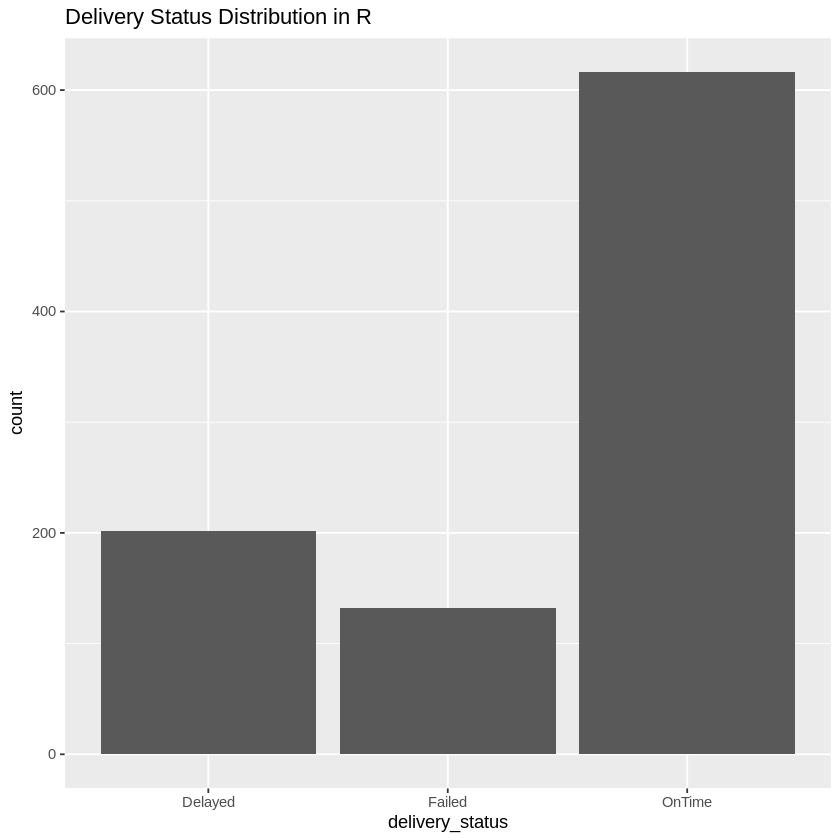

In [14]:
ggplot(deliveries, aes(x=delivery_status)) +
geom_bar() +
ggtitle("Delivery Status Distribution in R")